In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("driver-data.csv")
print (df.head())

           id  mean_dist_day  mean_over_speed_perc
0  3423311935          71.24                    28
1  3423313212          52.53                    25
2  3423313724          64.54                    27
3  3423311373          55.69                    22
4  3423310999          54.58                    25


<Axes: xlabel='mean_over_speed_perc', ylabel='mean_dist_day'>

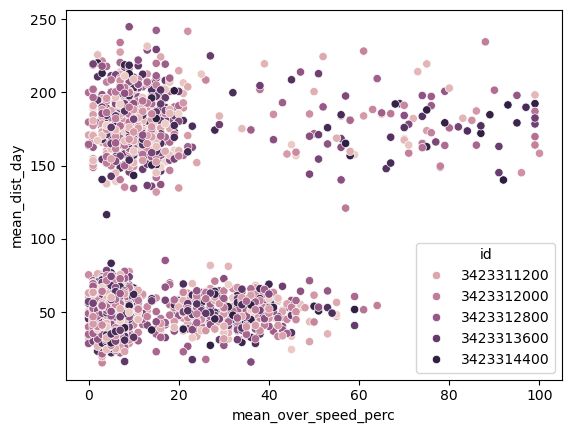

In [2]:
sns.scatterplot(data = df, x = 'mean_over_speed_perc', y = 'mean_dist_day', hue = 'id')

<Axes: xlabel='id', ylabel='mean_dist_day'>

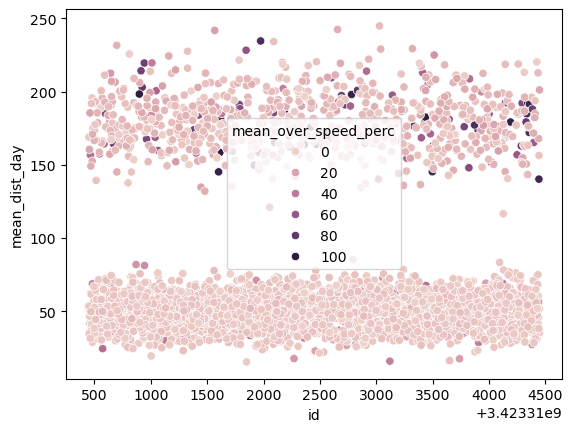

In [2]:
sns.scatterplot(data = df, x = 'id', y = 'mean_dist_day', hue = 'mean_over_speed_perc')

<Axes: xlabel='id', ylabel='mean_over_speed_perc'>

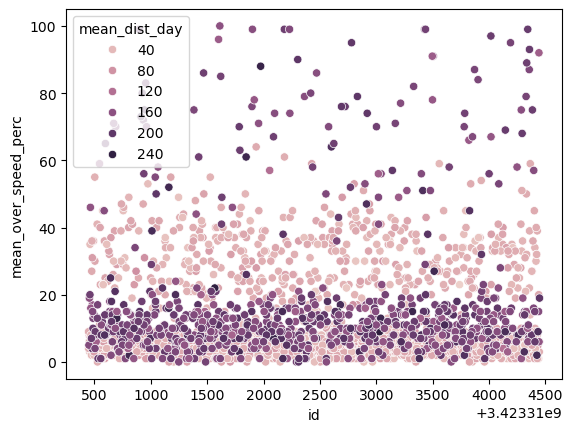

In [4]:
sns.scatterplot(data = df, x = 'id', y = 'mean_over_speed_perc', hue = 'mean_dist_day')

In [7]:
from sklearn.model_selection import train_test_split
X = df[['mean_over_speed_perc','mean_dist_day']]    
y = df[["id"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

In [8]:
from sklearn import preprocessing

X_train_norm = preprocessing.normalize(X_train)
X_test_norm = preprocessing.normalize(X_test)

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 2, random_state = 0, n_init='auto')
kmeans.fit(X_train_norm)

KMeans(n_clusters=2, random_state=0)

<Axes: xlabel='mean_dist_day', ylabel='mean_over_speed_perc'>

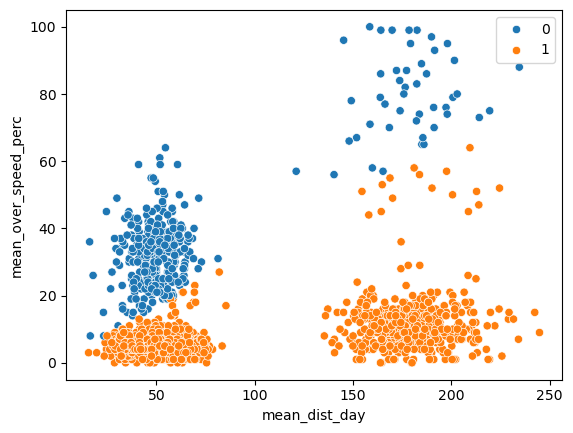

In [11]:
sns.scatterplot(data = X_train, x = 'mean_dist_day', y = 'mean_over_speed_perc', hue = kmeans.labels_)
# sns.scatterplot(data = df, x = 'id', y = 'mean_dist_day', hue = 'mean_over_speed_perc')

<Axes: ylabel='id'>

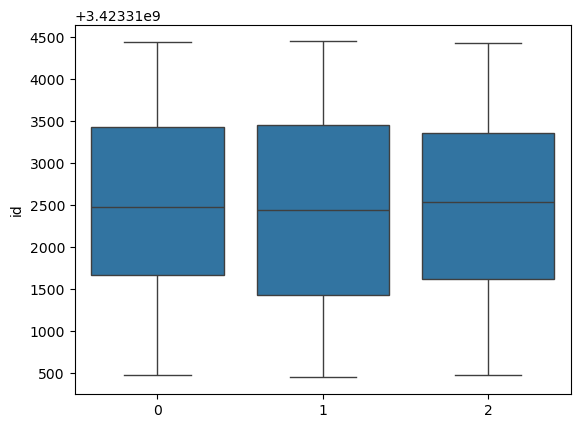

In [10]:
sns.boxplot(x = kmeans.labels_, y = y_train['id'])

In [15]:
from sklearn.metrics import silhouette_score

silhouette_score(X_train_norm, kmeans.labels_, metric='euclidean')

0.8250195149387145

In [16]:
K = range(2, 8)
fits = []
score = []


for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(X_train_norm)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(X_train_norm, model.labels_, metric='euclidean'))

<Axes: xlabel='mean_over_speed_perc', ylabel='mean_dist_day'>

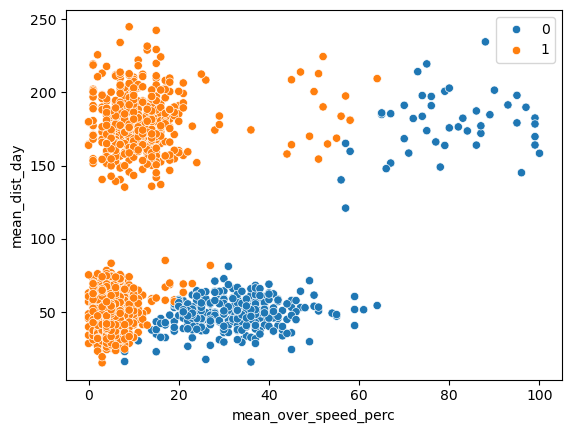

In [17]:
sns.scatterplot(data = X_train, x = 'mean_over_speed_perc', y = 'mean_dist_day', hue = fits[0].labels_)

<Axes: xlabel='mean_over_speed_perc', ylabel='mean_dist_day'>

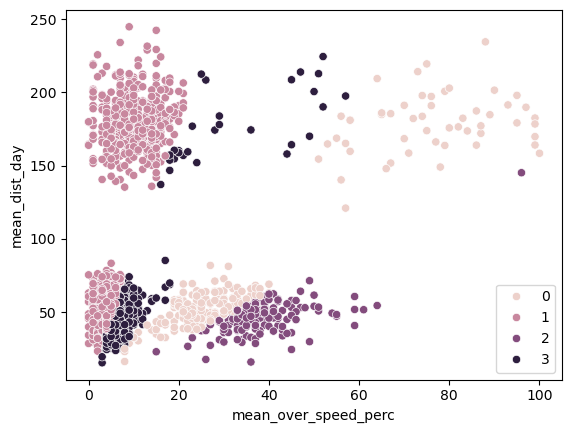

In [18]:
sns.scatterplot(data = X_train, x = 'mean_over_speed_perc', y = 'mean_dist_day', hue = fits[2].labels_)

<Axes: xlabel='mean_over_speed_perc', ylabel='mean_dist_day'>

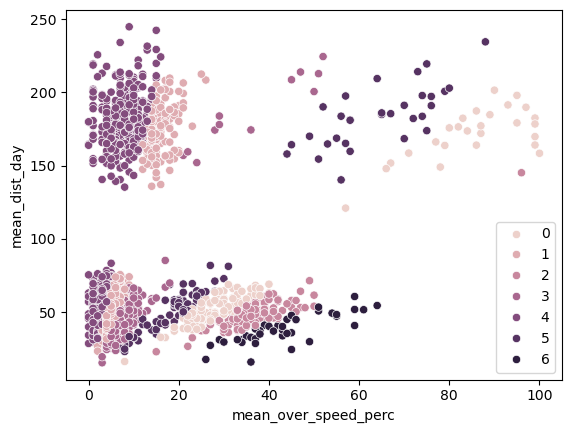

In [19]:
sns.scatterplot(data = X_train, x = 'mean_over_speed_perc', y = 'mean_dist_day', hue = fits[5].labels_)

<Axes: >

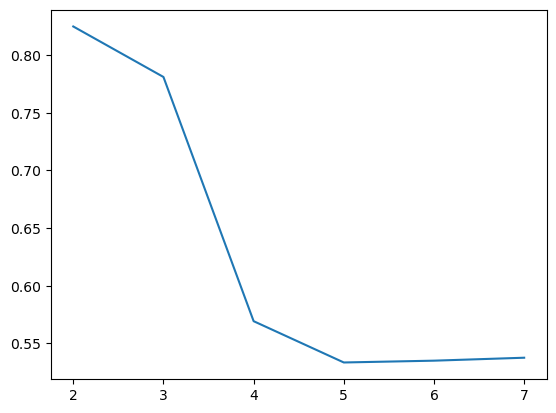

In [20]:
sns.lineplot(x = K, y = score)